In [2]:
import pandas as pd

df = pd.read_csv("../data/cleaned_project_dataset.csv")

df.describe()
print(df.columns)


print(f"Earliest match: {df["date"].min()}")

df["tournament_name"].value_counts()

df[df["penalty_shootout"] == True]
# df[df["year"]>= 2010]

df["total_goals"] = df["home_goals"] + df["away_goals"]
print(df["total_goals"].max())



Index(['year', 'date', 'tournament_id', 'tournament_name', 'match_name',
       'stage', 'home_team', 'away_team', 'home_team_code', 'away_team_code',
       'home_goals', 'away_goals', 'score', 'result', 'home_team_win',
       'away_team_win', 'draw', 'extra_time', 'penalty_shootout',
       'score_penalties', 'stadium', 'stadium_id', 'stadium_name', 'city',
       'host_country', 'host_team', 'attendance', 'match_time', 'referee',
       'notes'],
      dtype='object')
Earliest match: 1930-07-13
11.0


In [ ]:
# games_germany_over5goals = df[(df["match_name"].str.contains("Germany")) & (df["home_goals"]>5)]
# games_germany_over5goals[["match_name", "score"]]


df["total_goals"] = df["home_goals"] + df["away_goals"]

#Filter for mask:
germany_matches = df["match_name"].str.contains("GERmany", case=False, na = False)#not case sensible anymore
over_5goals = df["total_goals"]>5

games_germany_over5goals = df[germany_matches & over_5goals]
print(games_germany_over5goals)

#Thats why I need "na=False", because there too many blank rows which are creating Errors
anzahl_nans = df['match_name'].isna().sum()
print(f"Anzahl der leeren Felder in 'match_name': {anzahl_nans}")




     year        date tournament_id      tournament_name  \
20   1934  1934-05-27       WC-1934  1934 FIFA World Cup   
42   1938  1938-06-09       WC-1938  1938 FIFA World Cup   
491  2002  2002-06-01       WC-2002  2002 FIFA World Cup   
550  2006  2006-06-09       WC-2006  2006 FIFA World Cup   
732  2014  2014-07-08       WC-2014  2014 FIFA World Cup   
839  2022  2022-12-01       WC-2022  2022 FIFA World Cup   

                 match_name        stage    home_team     away_team  \
20        Germany v Belgium  Round of 16      Germany       Belgium   
42    Switzerland v Germany  Round of 16  Switzerland       Germany   
491  Germany v Saudi Arabia  Group stage      Germany  Saudi Arabia   
550    Germany v Costa Rica  Group stage      Germany    Costa Rica   
732        Brazil v Germany  Semi-finals       Brazil       Germany   
839    Costa Rica v Germany  Group stage   Costa Rica       Germany   

    home_team_code away_team_code  ...  stadium_id           stadium_name  \
20  

In [ ]:

df["total_goals"] = df["home_goals"] + df["away_goals"]
max_total_goals = df["total_goals"].max()

#matches with most total goals:
match_most_goals = df[df["total_goals"] == max_total_goals]

#these matches only with the relevant information
match_most_goals[["date", "home_team", "away_team", "home_goals", "away_goals"]]


,date,home_team,away_team,home_goals,away_goals
36,1938-06-05,Brazil,Poland,6.0,5.0
253,1982-06-15,Hungary,El Salvador,10.0,1.0


In [ ]:
#Testing how to group

#Sorted by tournament_name (World Cup years) with mean of total_goals
mean_goals_per_tournament = df.groupby("tournament_name")["total_goals"].mean()
print(mean_goals_per_tournament)

sum_goals_per_tournament= df.groupby("tournament_name")["total_goals"].sum()
print(sum_goals_per_tournament.sort_values(ascending=False)) #Sorted by most goals first

#Stadium sorted by most visitors first
most_attendance_per_stadium = df.groupby("stadium")["attendance"].sum().sort_values(ascending=False)
most_attendance_per_stadium

tournament_name
1930 FIFA World Cup    3.888889
1934 FIFA World Cup    4.117647
1938 FIFA World Cup    4.625000
1950 FIFA World Cup    4.000000
1954 FIFA World Cup    4.833333
1958 FIFA World Cup    3.321429
1962 FIFA World Cup    2.851852
1966 FIFA World Cup    2.750000
1970 FIFA World Cup    2.583333
1974 FIFA World Cup    2.357143
1978 FIFA World Cup    2.678571
1982 FIFA World Cup    2.818182
1986 FIFA World Cup    2.547619
1990 FIFA World Cup    2.121951
1994 FIFA World Cup    2.745098
1998 FIFA World Cup    2.709677
2002 FIFA World Cup    2.616667
2006 FIFA World Cup    2.200000
2010 FIFA World Cup    2.253968
2014 FIFA World Cup    2.634921
2018 FIFA World Cup    2.645161
2022 FIFA World Cup    2.687500
2026 FIFA World Cup         NaN
Name: total_goals, dtype: float64
tournament_name
2022 FIFA World Cup    172.0
1998 FIFA World Cup    168.0
2014 FIFA World Cup    166.0
2018 FIFA World Cup    164.0
2002 FIFA World Cup    157.0
2010 FIFA World Cup    142.0
1994 FIFA World Cup    1

stadium
Estadio Azteca             1356255.0
Estádio do Maracanã        1332730.0
Rose Bowl                   740807.0
Estadio Jalisco             677456.0
Wembley Stadium             619998.0
                             ...    
Hard Rock Stadium                0.0
Gillette Stadium                 0.0
Levi's Stadium                   0.0
Lincoln Financial Field          0.0
SoFi Stadium                     0.0
Name: attendance, Length: 213, dtype: float64

In [ ]:
#Learning how to aggregate
analyze_tournaments = df.groupby("tournament_name").agg({
    "match_name": "count",
    "total_goals": "sum",
})


# "match_name" : "count", ist basically count of total_matches: 
analyze_tournaments.rename(columns={"match_name": "total_matches"}, inplace=True)

#Better way:
analyte_tournament = df.groupby("tournament_name").agg(
    total_matches = ("match_name", "count"),  #auto rename of column to "total_matches"
    total_goals = ("total_goals", "sum")
    mean_attendance = ("attendance", "mean")
)

analyze_tournaments.sort_values(by="total_goals", ascending=False)


analyze_tournaments

#Different way of using "agg" :
analyze_attendance_per_stadium = df.groupby("stadium").agg({
    "attendance": ["min", "max", "mean"] 
})
print(analyze_attendance_per_stadium)

,match_name,total_goals
tournament_name,,
2022 FIFA World Cup,42,172.0
1998 FIFA World Cup,62,168.0
2014 FIFA World Cup,63,166.0
2018 FIFA World Cup,62,164.0
2002 FIFA World Cup,60,157.0
2010 FIFA World Cup,63,142.0
1994 FIFA World Cup,51,140.0
2006 FIFA World Cup,60,132.0
1982 FIFA World Cup,44,124.0


In [3]:
#nunique vs count:

stadium_comparison = df.groupby("stadium").agg(
    unique_count_stadiums = ("stadium_name", "nunique"),  # "nunique" counts unique entries
    most_played_stadiums = ("stadium_name", "count")  # "count" counts all entries, including duplicates
)
print(stadium_comparison)

                                     unique_count_stadiums  \
stadium                                                      
?ita Stadium                                             1   
AT&T Stadium                                             0   
Ahmad bin Ali Stadium                                    0   
Ahmed bin Ali Stadium, Umm al-Afā'ī                      0   
Al Bayt Stadium                                          0   
...                                                    ...   
Wembley Stadium                                          1   
Westfalenstadion                                         1   
White City Stadium                                       1   
Zentralstadion                                           1   
Örjans Vall                                              1   

                                     most_played_stadiums  
stadium                                                    
?ita Stadium                                            3  
AT&T Stadium 

In [ ]:
#Pivot

pivot_table = df.pivot_table(
    index = "tournament_name",
    values = "total_goals",
    columns = "stage",
    aggfunc= "mean"
)
#Show pivot table with mean of total goals per stage sorted by tournament:
pivot_table.round(1)

filtered_tournaments = df[df["tournament_name"].isin(["2018 FIFA World Cup", "20 FIFA World Cup"])]

pivot_table_filtered = filtered_tournaments.pivot_table(
    values = "attendance",
    index = "date",
    columns= "tournament_name",
    aggfunc= "mean"
)
pivot_table_filtered.round(1)

tournament_name,2018 FIFA World Cup,2022 FIFA World Cup
stage,,
Final,78011.0,NaN
Group stage,45227.0,51266.0
Quarter-finals,42618.0,NaN
Round of 16,45668.0,NaN
Semi-finals,71148.0,NaN
Third place,64406.0,NaN
final,NaN,88966.0
group stage,NaN,55618.0
quarter-finals,NaN,61305.0


(60.0, 65.0)

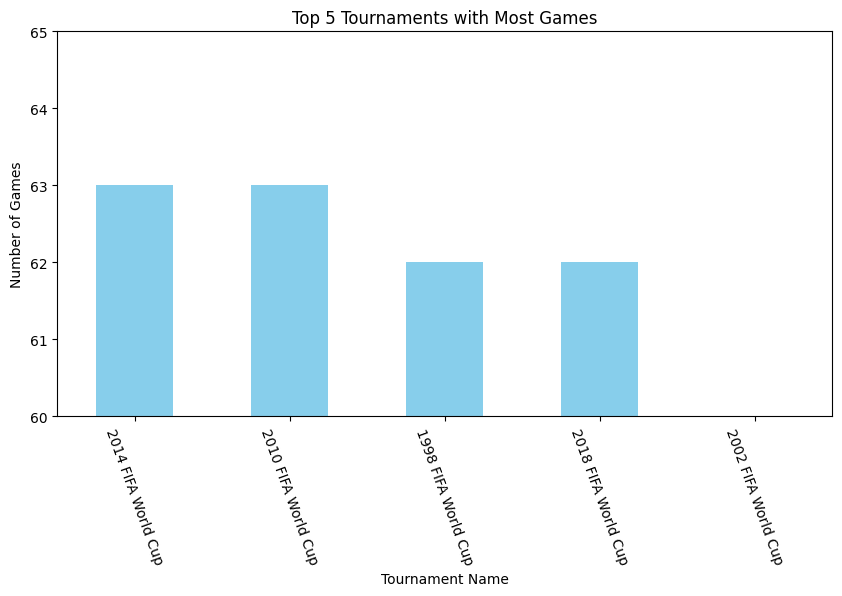

In [ ]:
import matplotlib.pyplot as plt

most_games_tournaments = df.groupby("tournament_name")["match_name"].count().sort_values(ascending=False)
top5_most_games_tournaments = most_games_tournaments.head(5)
top5_most_games_tournaments.plot(kind="bar",figsize=(10,5), color="skyblue")
plt.title("Top 5 Tournaments with Most Games")
plt.xlabel("Tournament Name")
plt.ylabel("Number of Games")
plt.xticks(rotation=290)
plt.ylim(60, 65)  #Zooming in for better vizualization